In [1]:
from __future__ import annotations
from typing import Iterable, Callable

import random
import numpy as np
import pandas as pd
from math import log
import networkx as nx
from scipy.stats import pearsonr
from itertools import combinations
from sklearn.metrics import adjusted_rand_score

from freyrelab.regnets import regnet
from freyrelab.regnets.abasy import Abasy
from freyrelab.regnets.regnet import RegNet
from freyrelab.nets import models, dissimilarity

from netective.utils import get_clusters
from netective.structure.structure import association, compare_networks, create_symmetric_heatmap

In [2]:
G = nx.erdos_renyi_graph(100, 0.1, directed=True)
H = nx.erdos_renyi_graph(100, 0.2, directed=True)

dissimilarity.graph_dissimilarity?

Signature:
dissimilarity.graph_dissimilarity(
    G,
    H,
    weights=(0.45, 0.45, 0.1),
    complement=True,
    kdir=None,
)
Docstring:
Returns the dissimilarity between two graphs according [#STA_NC_17]_.

Graph dissimilarity :math:`D(G,H)` between :math:`G` and :math:`H` is computed as

.. math:: w_{1}\sqrt{\frac{\mathrm{D_{JS}} (\mu_{G}, \mu_{H})}{\log 2}}+w_{2}\left | \sqrt{NND(G)} - \sqrt{NND(H)} \right |+\frac{w_{3}}{2}\left ( \sqrt{\frac{\mathrm{D_{JS}} (\mathbf{P}_{\alpha G}, \mathbf{P}_{\alpha H})}{\log 2}}+ \sqrt{\frac{\mathrm{D_{JS}} (\mathbf{P}_{\alpha G^{c}}, \mathbf{P}_{\alpha H^{c}})}{\log 2}} \right )

where :math:`\mathbf{P}_i=\{p_i(j)\}`, with :math:`p_i(j)` being the fraction of nodes that are connected to node :math:`i` at distance :math:`j`, :math:`\mu_{j}=\frac{\sum_{i=1}^{N}p_i(j)}{N}` is the average of the distributions, and :math:`NND(G)=\frac{\mathrm{D_{JS}} (\mathbf{P}_{1},\dots ,\mathbf{P}_{N})}{\log (d+1)}` is the network node dispersion of graph G wher

## Networks set

In [3]:
abasy = Abasy(db='abasy_internal', expire_cache=True)
regnet_ids = abasy.select_regnets(nr_strong_wa=True)    # select all regnets without redundancy, keep the strong one if available
regnets = abasy.regnet(regnet_ids)                      # get the regnets {regnet_id: RegNet}


seed = 42
random.seed(seed)
random_graph = {}
hm_seed_size = 3

for net_id, G in regnets.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    random_graph[f'BA_{net_id}'] = models.barabasi_albert_graph(n)
    random_graph[f'SF_{net_id}'] = nx.DiGraph(nx.scale_free_graph(n, seed=seed))
    random_graph[f'ER_{net_id}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)
    random_graph[f'HM_{net_id}'] = models.hierarchical_modular_graph(int(log(n, hm_seed_size))-1, m=hm_seed_size)

networks = {**regnets, **random_graph}
networks = {name: RegNet(G) if not isinstance(G, (nx.DiGraph,RegNet)) else G for name, G in networks.items()}

## Compare networks with Netective

In [4]:
scalar, dists = compare_networks(networks=networks, norm='network', return_prop_dicts=True, workers=6)

Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



  0%|          | 0/7 [00:00<?, ?it/s]

Running 100226_v2019_sA22-DBSCR15_eStrong
Running 158878_v2015_sRTB13
Running 158879_v2015_sRTB13
Running 160491_v2015_sRTB13
Running 186103_v2015_sRTB13
Running 196620_v2015_sRTB13
Running 196627_v2020_s21_eStrong
Running 198466_v2015_sRTB13
Running 199310_v2015_sRTB13
Running 208964_v2020_sRPA20_eStrong
Running 224308_v2008_sDBTBS08_eStrong
Running 273036_v2015_sRTB13
Running 282458_v2015_sRTB13
Running 282459_v2015_sRTB13
Running 301447_v2015_sRTB13
Running 316385_v2015_sRTB13
Running 319701_v2015_sRTB13
Running 331111_v2015_sRTB13
Running 331112_v2015_sRTB13
Running 340184_v2015_sRTB13
Running 344601_v2015_sRTB13
Running 359786_v2015_sRTB13
Running 359787_v2015_sRTB13
Running 362663_v2015_sRTB13
Running 364106_v2015_sRTB13
Running 367830_v2015_sRTB13
Running 370551_v2015_sRTB13
Running 370552_v2015_sRTB13
Running 370554_v2015_sRTB13
Running 381754_v2015_sRTB13
Running 405955_v2015_sRTB13
Running 406558_v2015_sRTB13
Running 418127_v2015_sRTB13
Running 426430_v2015_sRTB13
Running 439

33it [00:07,  6.01it/s]                      

Error: cannot pickle 'dict_keys' object


208it [04:57,  1.43s/it]


c:\Users\jmere\.conda\envs\pyfl38\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


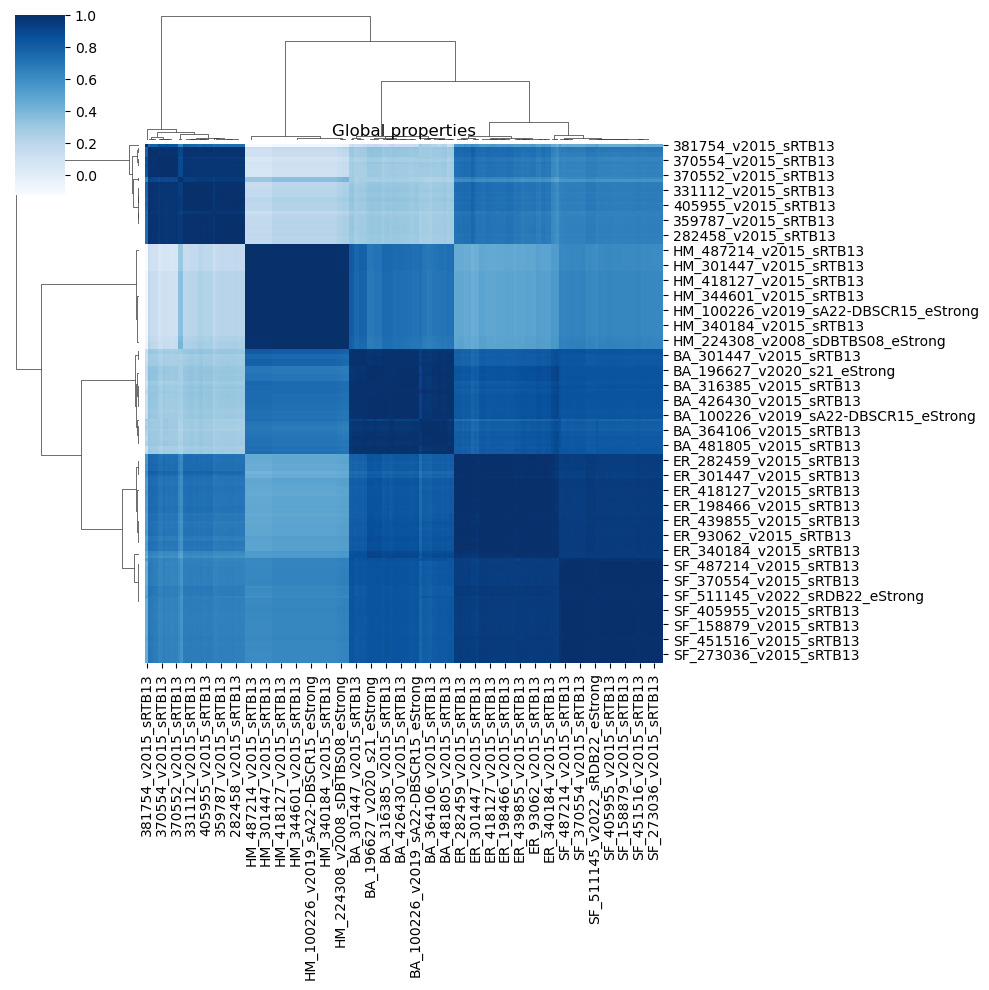

In [5]:
df = association(scalar, corr_func=pearsonr)
fig_scalar, _ = create_symmetric_heatmap(df, title=f"Global properties")

In [27]:
models = {'BA' : 0, 'SF' : 1, 'ER' : 2, 'HM' : 3} # Every biological network id starts with a number
gs = [models.get(name.split('_')[0], 4) for name in df.index] # 4 for biological
example_netid = '160491_v2015_sRTB13' # to get properties name
n_clusters = 5 # number of clusters to be obtained


# combinatory of scalar properties
props_combinatory = combinations(scalar[example_netid].keys(), 2) ####EL " DEBE IR HASTA EL 18 o las props que sean!!!"

rand_combinatory = {}
for props_subset in props_combinatory:
    
    scalar_subset = {
        net_id: {
            prop_name: value
            for prop_name, value in scalar[net_id].items()
            if prop_name in props_subset
        }
        for net_id in scalar.keys()
    }

    df_subset = association(scalar_subset)
    result_subset = get_clusters(df_subset, n_clusters, map_ids=False)
    rand_combinatory[props_subset] = adjusted_rand_score(gs, result_subset)

c:\Users\jmere\.conda\envs\pyfl38\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


ValueError: Distance matrix 'X' must be symmetric.

In [84]:
np.isfinite(1.2233003984167067e-08)

True

In [81]:
scalar_subset

{'186103_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '160491_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '198466_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '199310_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '196620_v2015_sRTB13': {'Complex Feed-Forward Circuits': 6.997141667628773e-07,
  '3-Feedback Loops': 4.664761111752516e-08},
 '158878_v2015_sRTB13': {'Complex Feed-Forward Circuits': 6.116997127878692e-07,
  '3-Feedback Loops': 3.8231232049241825e-08},
 '158879_v2015_sRTB13': {'Complex Feed-Forward Circuits': 2.7416339041415123e-07,
  '3-Feedback Loops': 1.9583099315296516e-08},
 '100226_v2019_sA22-DBSCR15_eStrong': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '301447_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '282458_v2015_sRTB13': {'Complex Feed-Forward Circuits'

In [85]:
scalar_subset

{'186103_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '160491_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '198466_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '199310_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '196620_v2015_sRTB13': {'Complex Feed-Forward Circuits': 6.997141667628773e-07,
  '3-Feedback Loops': 4.664761111752516e-08},
 '158878_v2015_sRTB13': {'Complex Feed-Forward Circuits': 6.116997127878692e-07,
  '3-Feedback Loops': 3.8231232049241825e-08},
 '158879_v2015_sRTB13': {'Complex Feed-Forward Circuits': 2.7416339041415123e-07,
  '3-Feedback Loops': 1.9583099315296516e-08},
 '100226_v2019_sA22-DBSCR15_eStrong': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '301447_v2015_sRTB13': {'Complex Feed-Forward Circuits': 0.0,
  '3-Feedback Loops': 0.0},
 '282458_v2015_sRTB13': {'Complex Feed-Forward Circuits'

In [80]:
df_subset

,186103_v2015_sRTB13,160491_v2015_sRTB13,198466_v2015_sRTB13,199310_v2015_sRTB13,196620_v2015_sRTB13,158878_v2015_sRTB13,158879_v2015_sRTB13,100226_v2019_sA22-DBSCR15_eStrong,301447_v2015_sRTB13,282458_v2015_sRTB13,...,ER_511145_v2022_sRDB22_eStrong,BA_93062_v2015_sRTB13,SF_93062_v2015_sRTB13,SF_511145_v2022_sRDB22_eStrong,HM_93062_v2015_sRTB13,ER_93062_v2015_sRTB13,BA_83332_v2018_s11-12-15-16,SF_83332_v2018_s11-12-15-16,HM_83332_v2018_s11-12-15-16,ER_83332_v2018_s11-12-15-16
186103_v2015_sRTB13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160491_v2015_sRTB13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
198466_v2015_sRTB13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199310_v2015_sRTB13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196620_v2015_sRTB13,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,1.0,...,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ER_93062_v2015_sRTB13,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0,NaN,NaN,-1.0,...,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BA_83332_v2018_s11-12-15-16,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0,NaN,NaN,-1.0,...,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
SF_83332_v2018_s11-12-15-16,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0,NaN,NaN,-1.0,...,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
HM_83332_v2018_s11-12-15-16,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0,NaN,NaN,-1.0,...,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [60]:
foo = df_subset.replace([np.inf, -np.inf], np.nan, inplace=False)
foo = foo.fillna(0, inplace=False)
foo

,186103_v2015_sRTB13,160491_v2015_sRTB13,198466_v2015_sRTB13,199310_v2015_sRTB13,196620_v2015_sRTB13,158878_v2015_sRTB13,158879_v2015_sRTB13,100226_v2019_sA22-DBSCR15_eStrong,301447_v2015_sRTB13,282458_v2015_sRTB13,...,ER_511145_v2022_sRDB22_eStrong,BA_93062_v2015_sRTB13,SF_93062_v2015_sRTB13,SF_511145_v2022_sRDB22_eStrong,HM_93062_v2015_sRTB13,ER_93062_v2015_sRTB13,BA_83332_v2018_s11-12-15-16,SF_83332_v2018_s11-12-15-16,HM_83332_v2018_s11-12-15-16,ER_83332_v2018_s11-12-15-16
186103_v2015_sRTB13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160491_v2015_sRTB13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
198466_v2015_sRTB13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
199310_v2015_sRTB13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
196620_v2015_sRTB13,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,...,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ER_93062_v2015_sRTB13,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,-1.0,...,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BA_83332_v2018_s11-12-15-16,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,-1.0,...,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
SF_83332_v2018_s11-12-15-16,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,-1.0,...,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
HM_83332_v2018_s11-12-15-16,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,-1.0,...,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [61]:
def check_symmetric(a):

    diff = a - a.T

    boolmatrix = np.isclose(a, a.T) # play around with your tolerances here...

    output = np.argwhere(boolmatrix == False)

    return output 

check_symmetric(foo.astype("float").to_numpy())

array([], shape=(0, 2), dtype=int64)

In [62]:
np.isclose(np.nan, np.nan)

False

In [63]:
np.nan == np.nan

False

In [79]:
pearsonr([1,0],[1,np.nan])

# alguna propiedad sesta regresando nan y eso causa que se esté propagando

PearsonRResult(statistic=nan, pvalue=1.0)

In [56]:
df = df_subset.astype("float")

df.columns.to_series()[np.isnan(df).any()]

186103_v2015_sRTB13                    186103_v2015_sRTB13
160491_v2015_sRTB13                    160491_v2015_sRTB13
198466_v2015_sRTB13                    198466_v2015_sRTB13
199310_v2015_sRTB13                    199310_v2015_sRTB13
196620_v2015_sRTB13                    196620_v2015_sRTB13
                                          ...             
ER_93062_v2015_sRTB13                ER_93062_v2015_sRTB13
BA_83332_v2018_s11-12-15-16    BA_83332_v2018_s11-12-15-16
SF_83332_v2018_s11-12-15-16    SF_83332_v2018_s11-12-15-16
HM_83332_v2018_s11-12-15-16    HM_83332_v2018_s11-12-15-16
ER_83332_v2018_s11-12-15-16    ER_83332_v2018_s11-12-15-16
Length: 208, dtype: object

In [ ]:
# index = list(corr_df.index)
models = {
    'BA' : 0,
    'SF' : 1,
    'ER' : 2,
    'HM' : 3,
    }

gs = [models.get(name.split('_')[0], 4) for name in df.index] # 4 for biological
result = get_clusters(df, 5, map_ids=False) # 5 clusters

adjusted_rand_score(gs, result)


C:\Users\jmere\AppData\Local\Temp\ipykernel_22972\4063097653.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


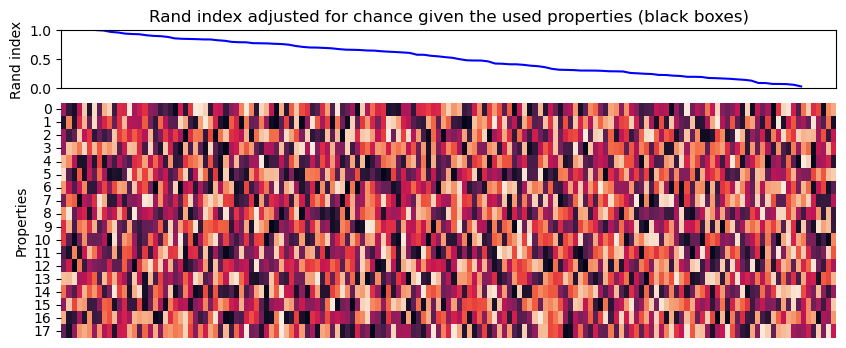

In [78]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate random data for the heatmap
data = np.random.rand(18, 153)

# Generate random words for y-axis labels
y_labels = [str(i) for i in range (18)]

# Generate random data for the decreasing function
x = np.linspace(0, 1, 100)
y = np.sort(np.random.rand(100))[::-1]

# Create a figure with a shared x-axis
fig = plt.figure(figsize=(10, 4))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 8], hspace=0.1)  # Swapped height_ratios

# Plot the decreasing function in the first row
ax2 = fig.add_subplot(gs[0])
ax2.plot(x, y, color='blue')
ax2.set_title('Rand index adjusted for chance given the used properties (black boxes)')
ax2.set_ylabel('Rand index')
ax2.set_xticks([])
ax2.set_ylim(0, 1)

# Plot the heatmap in the second row
ax1 = fig.add_subplot(gs[1])
sns.heatmap(data, ax=ax1, cbar=False)  # Set cbar=False to remove colorbar
ax1.set_ylabel('Properties')
ax1.set_yticks(np.arange(18) + 0.5)
ax1.set_yticklabels(y_labels, rotation=0)
ax1.set_xticks([])

plt.tight_layout()
plt.show()


### en el eje x, sortea los valores de mayor a menor según el rand score, después de menor a menor en el número de props usadas

In [61]:
sns.heatmap(data, cmap='viridis', ax=ax1)
plt.show()

In [55]:
data

array([[0.06825847, 0.68598631, 0.8555308 , ..., 0.09327741, 0.88864054,
        0.01231296],
       [0.67518015, 0.61587069, 0.97337356, ..., 0.66248021, 0.22822243,
        0.973453  ],
       [0.00417011, 0.11501871, 0.02331705, ..., 0.86763568, 0.90219322,
        0.41679235],
       ...,
       [0.4217219 , 0.38720824, 0.86312877, ..., 0.13669422, 0.56080381,
        0.86152594],
       [0.56955576, 0.4686406 , 0.06813364, ..., 0.86477865, 0.06087731,
        0.3963916 ],
       [0.32074509, 0.55996066, 0.97420473, ..., 0.09770483, 0.62815205,
        0.20565858]])